# 📊 Tarea paso a paso: Gráficos Joint Plot

**¡ATENCIÓN! Lee esto antes de empezar:**
Esta tarea está diseñada paso a paso para que afiances los conceptos vistos en clase sobre los `Joint Plots`. Su objetivo es que practiques cómo realizar un análisis bivariante (relación entre dos variables) sin perder de vista la distribución univariante (histograma) de cada una de ellas simultáneamente.

⚠️ **Nota importante sobre la Inteligencia Artificial:**
Es tentador copiar y pegar el enunciado de estos ejercicios en ChatGPT o Claude para que te den la solución... **Hacer eso perjudicará gravemente tu aprendizaje. (CODEA UN POCO QUE TE ENTERES QUE HACES)**. La única forma de asimilar la sintaxis de las herramientas de visualización es escribiéndolas. **Usa tu cerebro, actúa paso a paso, equivócate, lee la documentación de Seaborn, busca tu fallo y ¡aprende de él!**

## 📁 Preparación y Datos

Para esta tarea vamos a utilizar el dataset **"Students Performance in Exams"** de Kaggle.
Es ideal para evaluar resultados numéricos con correlaciones muy fuertes y ver cómo se distribuyen las calificaciones.

1. Descarga el dataset de Kaggle: [Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)
2. Guarda el archivo `StudentsPerformance.csv` (o el nombre que venga por defecto) en la carpeta `data/` de tu proyecto.
3. En la siguiente celda, importa las librerías necesarias (`pandas`, `matplotlib.pyplot`, `seaborn`) y carga el CSV en un DataFrame llamado `df`. Imprime las primeras filas para revisar los nombres de las columnas, prestando atención a variables como `math score`, `reading score` y `gender`.

In [1]:
# Importamos pandas para trabajar con el dataset
import pandas as pd
# Importamos seaborn para crear los gráficos
import seaborn as sns
# Importamos matplotlib para apoyar la visualización
import matplotlib.pyplot as plt

# Configuramos un estilo sencillo para seaborn
sns.set_style("whitegrid")

# Cargamos el archivo CSV de estudiantes
df = pd.read_csv("data/StudentsPerformance.csv")

# Mostramos las primeras filas para revisar los datos
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 🛠️ Paso 1: Joint Plot Básico (Dispersión e Histogramas)

**Objetivo:** Obtener una visión completa que combine cómo se relacionan las notas de matemáticas y lectura, y cuán frecuentes son ciertas notas.

**Instrucciones:**
1. Crea un gráfico utilizando la función `seaborn.jointplot`.
2. Asigna la puntuación de matemáticas (`math score`) al eje X y la puntuación de lectura (`reading score`) al eje Y.
3. Observa la nube de puntos central (correlación) y fíjate en las barras de los márgenes superior y derecho (distribuciones de cada nota por separado).

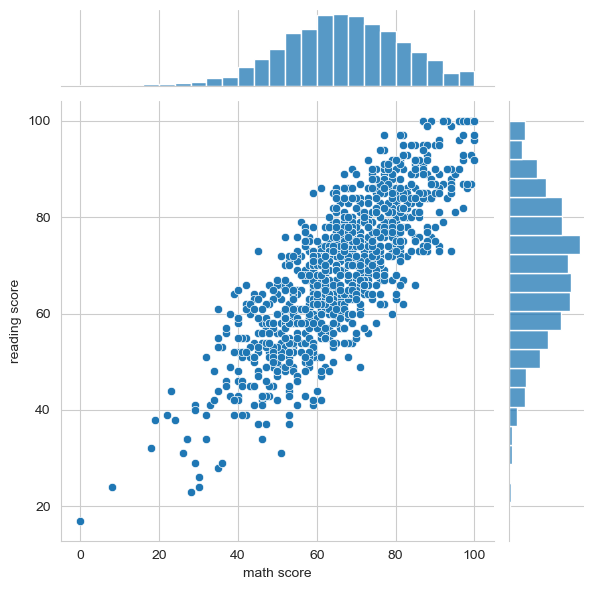

In [ ]:
# Creamos un joint plot básico
# Más info sobre jointplot en la documentación de Seaborn:
#  https://seaborn.pydata.org/generated/seaborn.jointplot.html
sns.jointplot(
    data=df,
    x='math score',
    y='reading score'
)


## 🛠️ Paso 2: Explorando otros tipos de Joint Plot (Kind)

**Objetivo:** Cambiar la representación del gráfico central y de los bordes para resaltar concentraciones (densidad) de datos en lugar de mostrar puntos sueltos.

**Instrucciones:**
1. Repite la creación del gráfico del Paso 1.
2. Añade el parámetro `kind="kde"` (Kernel Density Estimate) o `kind="hex"` (Hexbin plot).
3. Nota cómo los márgenes ahora también pueden adaptarse a curvas de densidad en lugar de simples histogramas. ¿Dónde se nota la mayor aglomeración de estudiantes?

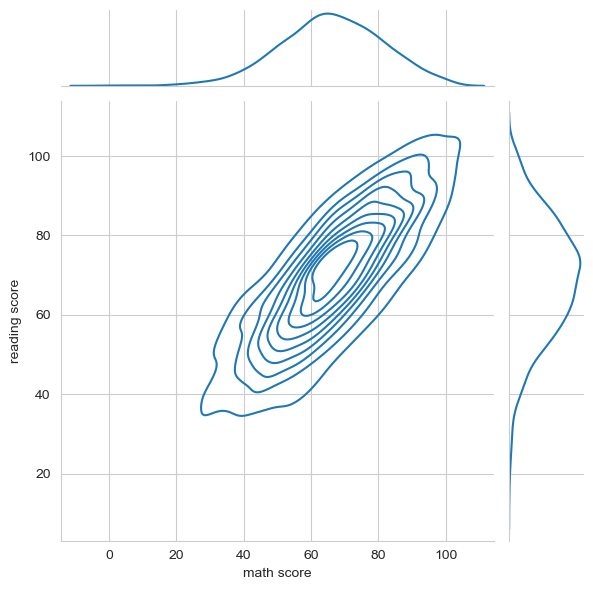

In [3]:
# Creamos un joint plot cambiando el tipo del gráfico
# Usamos kind='kde' para ver mejor la densidad de los datos
sns.jointplot(
    data=df,
    x='math score',
    y='reading score',
    kind='kde'
)


## 🛠️ Paso 3: Agregando la dimensión Categórica (Hue)

**Objetivo:** Dividir las distribuciones y correlaciones para ver si hay un comportamiento distinto entre dos grupos.

**Instrucciones:**
1. Vuelve al modelo base que usaste en el Paso 1 (con puntos/scatter, es decir, obvia el parámetro `kind` o ponlo a `scatter`).
2. Añade el parámetro `hue` y asígnale la columna de género (`gender`) o de curso de preparación (`test preparation course`).
3. Analiza cómo Seaborn dibuja ahora dos histogramas o densidades en los márgenes superpuestas para poder comparar a simple vista la diferencia univariada y cómo divide la nube de puntos.

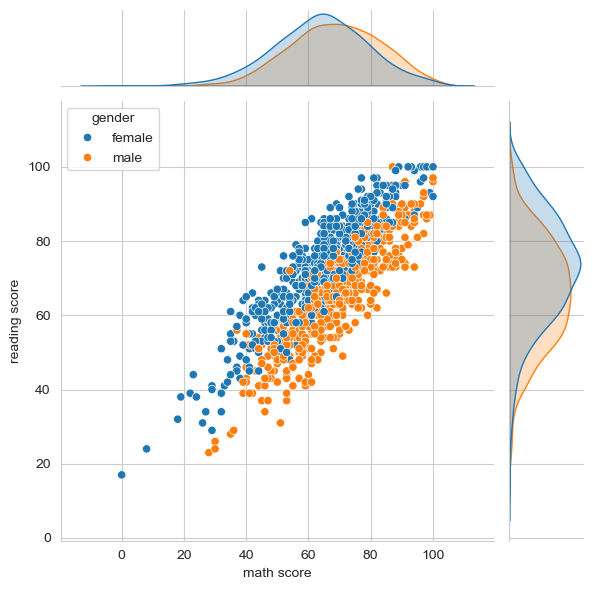

In [4]:
# Creamos un joint plot separando los datos por género
sns.jointplot(
    data=df,
    x='math score',
    y='reading score',
    hue='gender'
)


## 🛠️ Paso 4: Customización avanzada utilizando los parámetros `kws`

**Objetivo:** Como un Joint Plot está formado por distintos sub-gráficos, practicar cómo pasarle diccionarios de configuración (`kws`) específicos a cada parte.

**Instrucciones:**
1. Haz un `jointplot` básico (X: `math score`, Y: `reading score`).
2. Configura el color principal a uno que te guste (ej. `color="purple"`) y un tamaño global (`height=8`).
3. Para hacer los puntos de dispersión más grandes y un poco transparentes, usa el diccionario `joint_kws={'s': 50, 'alpha': 0.6}`.
4. Para modificar los histogramas de los márgenes y cambiar, por ejemplo, los bordes de la barras o el relleno, haz uso del diccionario `marginal_kws={'fill': True, 'color': 'orange'}`.

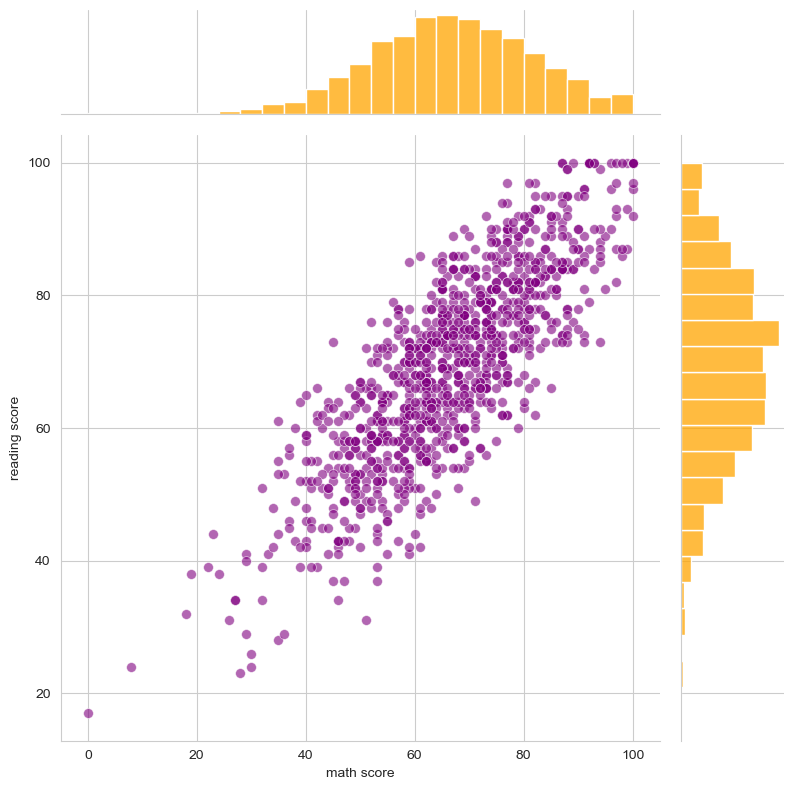

In [5]:
# Creamos un joint plot personalizado
sns.jointplot(
    data=df,
    x='math score',
    y='reading score',
    color='purple',
    height=8,
    joint_kws={'s': 50, 'alpha': 0.6},
    marginal_kws={'fill': True, 'color': 'orange'}
)


## 🌟 Reflexión Final del Alumno

**Tómate un rato.** 
Como has podido notar en esta lección:
* Una **gráfica Joint Plot** es una de las herramientas más "completas" de Seaborn al fusionar análisis bivariado y univariado de un solo vistazo.
* Es ideal en tu futuro análisis exploratorio (EDA) cuando te pregunten "no solo quiero saber cómo se relacionan estas dos métricas de negocio, sino qué forma tiene cada una por separado".
* Modificar el atributo `kind` a `hex` o `kde` es extremadamente útil cuando tienes miles o decenas de miles de datos y el `scatter` habitual es solo un borrón manchado e ininteligible.

**Asegúrate que tu código de las celdas anteriores esté exhaustivamente comentado por ti en cada paso importante...**

## REFLEXION FINAL
- Gracias a Jointplot vemos muy bien a simple vista cómo se distribuyen datos en dos ejes que pintemos, en X e Y , por ejemplo en nuestro caso math score con reading score, y cómo se distribuyen en el grid central los datos.
- Podemos en cualquier caso ver que correlacionan fuertemente la capacidad lectora con la matemática. Hay una relación lineal muy visible en el segundo gráfico de KDE 
- Se observa también en las eparación hombre / mujer que es mayor la capacidad lectora de la mujer, ligeramente. En matemáticas, algo más de equilibrio
- En el scatter final se confirma lo estudiado antes. hay outliers con puntuaciones muy bajas, pero el patrón es consistente